<a href="https://colab.research.google.com/github/Everestino/Python/blob/main/AluraStoreBrasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

lojas_nomes=['Loja 1','Loja 2','Loja 3','Loja 4']

#1. Análise do faturamento



In [33]:
faturamento_nomes={'Loja1' : loja.Preço.sum().item(),'Loja2' : loja2.Preço.sum().item(),'Loja3' : loja3.Preço.sum().item(),'Loja4' : loja4.Preço.sum().item()}
faturamento_nomes


{'Loja1': 1534509.12,
 'Loja2': 1488459.06,
 'Loja3': 1464025.03,
 'Loja4': 1384497.58}

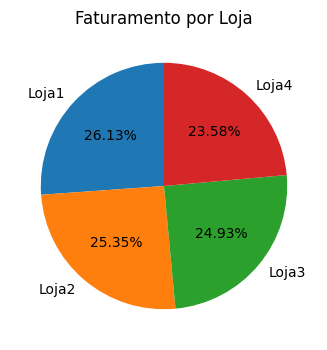

# 2. Vendas por Categoria

In [40]:
vendas_cat= [loja.groupby('Categoria do Produto')['Preço'].sum(),loja2.groupby('Categoria do Produto')['Preço'].sum(),loja3.groupby('Categoria do Produto')['Preço'].sum(),loja4.groupby('Categoria do Produto')['Preço'].sum()]
vendas_cat

[Categoria do Produto
 brinquedos                23993.78
 eletrodomesticos         484913.36
 eletronicos              572659.23
 esporte e lazer           52387.55
 instrumentos musicais    121731.69
 livros                    11713.92
 moveis                   250178.11
 utilidades domesticas     16931.48
 Name: Preço, dtype: float64,
 Categoria do Produto
 brinquedos                21262.21
 eletrodomesticos         464758.13
 eletronicos              547773.71
 esporte e lazer           46326.09
 instrumentos musicais    139987.03
 livros                    13454.35
 moveis                   235234.68
 utilidades domesticas     19662.86
 Name: Preço, dtype: float64,
 Categoria do Produto
 brinquedos                25869.20
 eletrodomesticos         438984.89
 eletronicos              547699.92
 esporte e lazer           47456.10
 instrumentos musicais    103174.45
 livros                    12664.70
 moveis                   268095.56
 utilidades domesticas     20080.21
 Name: Pre

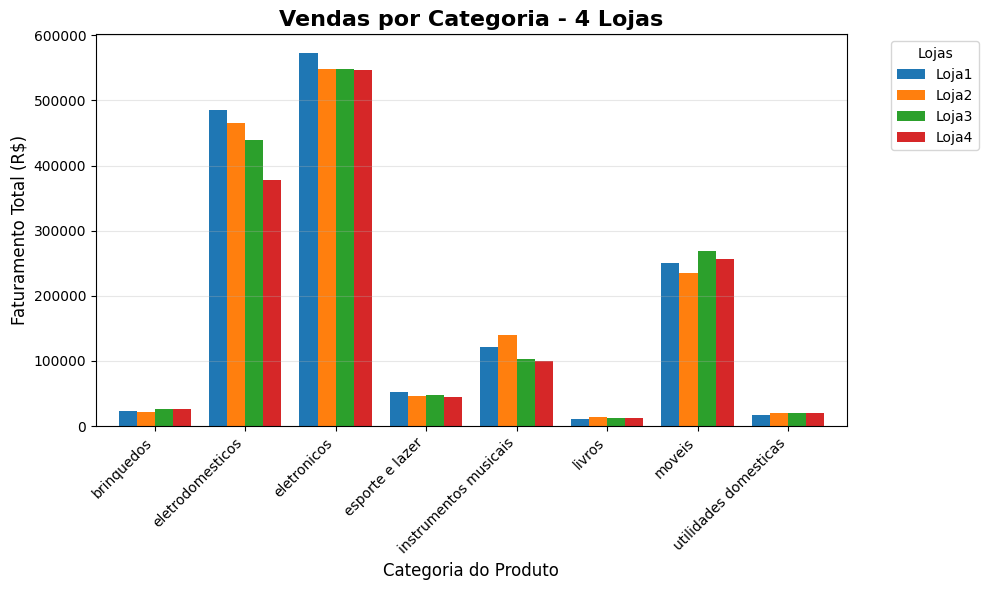

# 3. Média de Avaliação das Lojas


In [21]:
aval=[loja['Avaliação da compra'].mean().round(2).item(),loja2['Avaliação da compra'].mean().round(2).item(),loja3['Avaliação da compra'].mean().round(2).item(),loja4['Avaliação da compra'].mean().round(2).item()]

In [22]:
medias_avali={chave:valor for (chave,valor) in zip(lojas_nomes,aval)}
medias_avali



{'Loja 1': 3.98, 'Loja 2': 4.04, 'Loja 3': 4.05, 'Loja 4': 4.0}

# 4. Produtos Mais e Menos Vendidos

In [23]:
selecionando=loja['Produto'].value_counts().sort_values(ascending=False)
beastsealer=selecionando.iloc[[0, -1]]
beastsealer

,count
Produto,
Micro-ondas,60
Celular ABXY,33


In [50]:
lojas_produtos = pd.DataFrame({
    'Loja1': loja['Produto'].value_counts().iloc[[0, -1]],
    'Loja2': loja2['Produto'].value_counts().iloc[[0, -1]],
    'Loja3': loja3['Produto'].value_counts().iloc[[0, -1]],
    'Loja4': loja4['Produto'].value_counts().iloc[[0, -1]]
})


# 5. Frete Médio por Loja

In [48]:
fretes=[loja['Frete'].mean().round(2).item(),loja2['Frete'].mean().round(2).item(),loja3['Frete'].mean().round(2).item(),loja4['Frete'].mean().round(2).item()]

In [49]:
fretes_final={k:v for (k,v) in zip(lojas_nomes,fretes) }
fretes_final

{'Loja 1': 34.69, 'Loja 2': 33.62, 'Loja 3': 33.07, 'Loja 4': 31.28}

# Gráficos

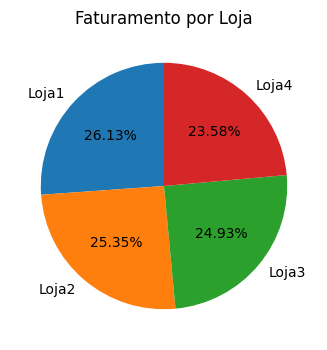

In [42]:
faturamento_total = pd.Series(faturamento_nomes)
plt.figure(figsize=(8, 4))
faturamento_total.plot(kind='pie', autopct='%1.2f%%', startangle=90, color=['skyblue', 'lightgreen', 'gold', 'tomato'])
plt.title('Faturamento por Loja')

plt.show()

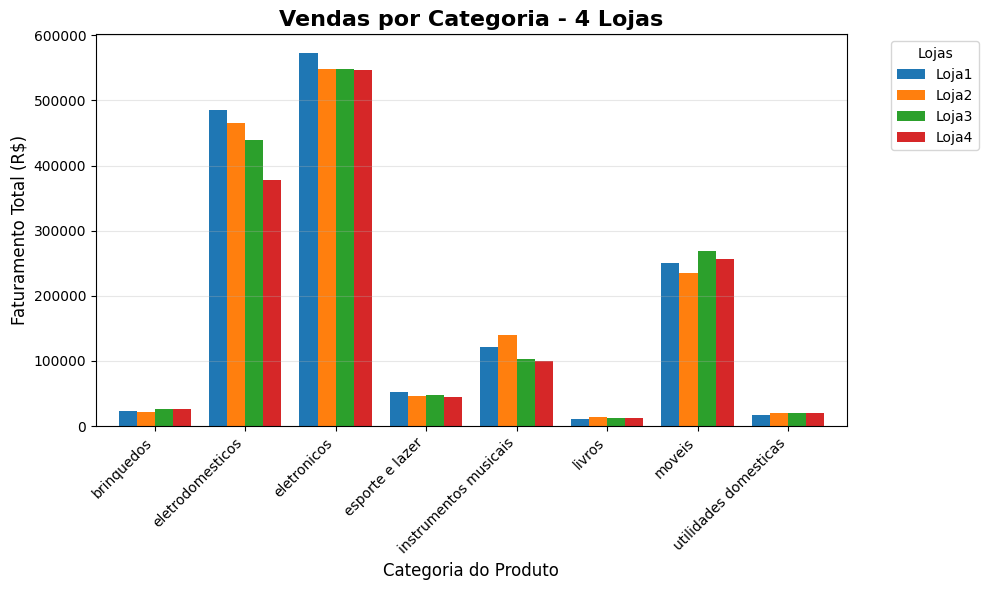

In [43]:
# Combinar em DataFrame
df_vendas = pd.DataFrame(vendas_cat).fillna(0).T
df_vendas.columns = ['Loja1', 'Loja2', 'Loja3', 'Loja4']

# Gráfico de barras agrupadas
df_vendas.plot(kind='bar', figsize=(10,6), width=0.8)
plt.title('Vendas por Categoria - 4 Lojas', fontsize=16, fontweight='bold')
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xlabel('Categoria do Produto', fontsize=12)
plt.legend(title='Lojas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

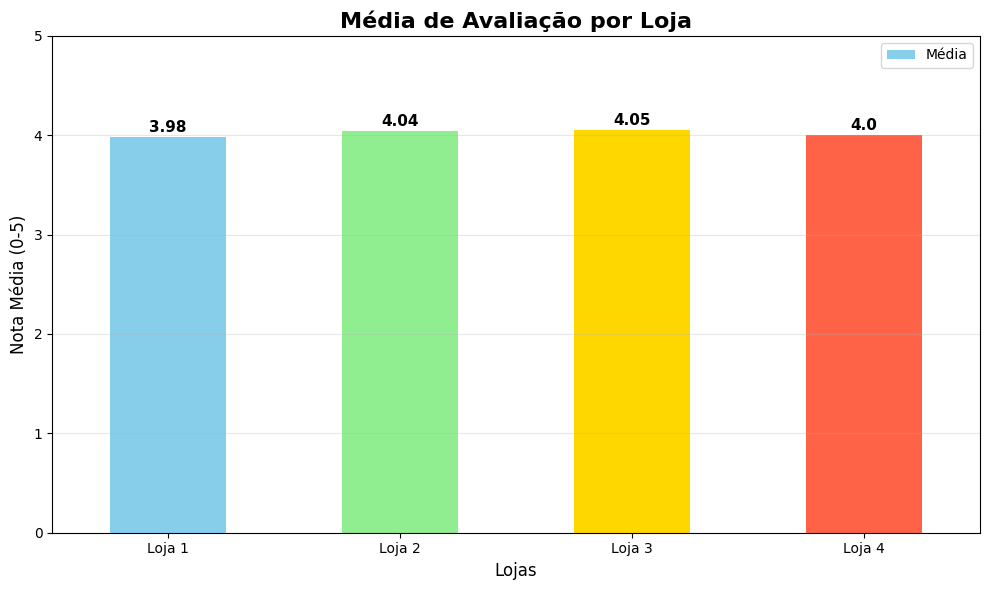

In [47]:
# DataFrame para gráfico
df_avali = pd.DataFrame(list(medias_avali.items()), columns=['Loja', 'Média'])

# Gráfico barras
colors=['skyblue', 'lightgreen', 'gold', 'tomato']
ax = df_avali.plot(x='Loja', y='Média', kind='bar', color=colors, figsize=(10,6))

plt.title('Média de Avaliação por Loja', fontsize=16, fontweight='bold')
plt.ylabel('Nota Média (0-5)', fontsize=12)
plt.xlabel('Lojas', fontsize=12)
plt.ylim(0, 5)
for i, v in enumerate(df_avali['Média']):
    ax.text(i, v + 0.05, f'{v}', ha='center', fontweight='bold', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()


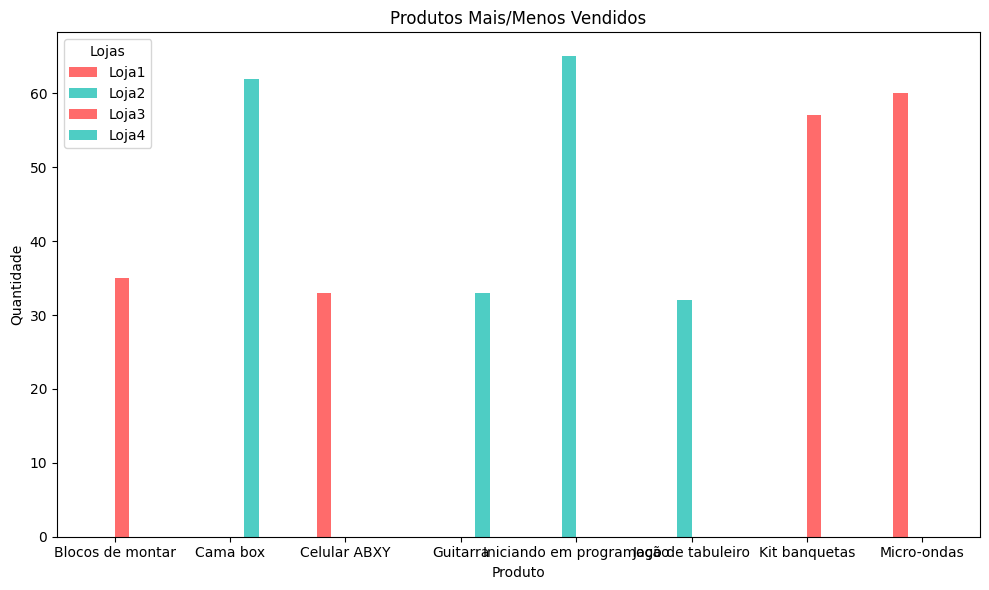

In [59]:
lojas_produtos.plot(kind='bar', figsize=(10,6), color=['#FF6B6B', '#4ECDC4'])
plt.title('Produtos Mais/Menos Vendidos')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(title='Lojas')
plt.tight_layout()
plt.show()

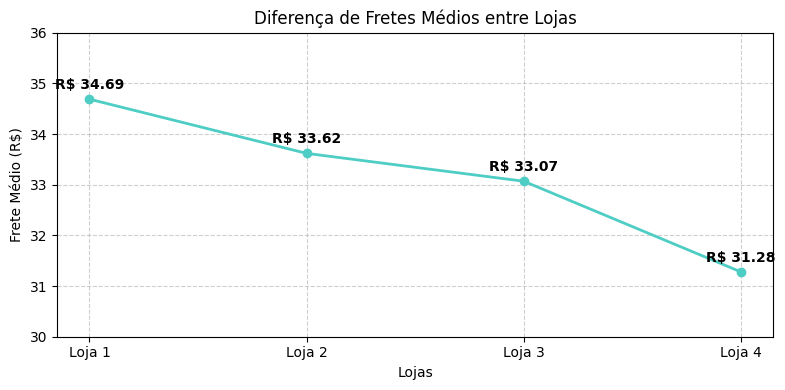

In [63]:
plt.figure(figsize=(8, 4))
plt.plot(list(fretes_final.keys()), list(fretes_final.values()),
         marker='o', linestyle='-', color='#4ECDC4', linewidth=2)

plt.ylim(30, 36)
plt.title('Diferença de Fretes Médios entre Lojas')
plt.xlabel('Lojas')
plt.ylabel('Frete Médio (R$)')
plt.grid(True, linestyle='--', alpha=0.6)

for loja_nome, valor_frete in fretes_final.items():
    plt.text(loja_nome, valor_frete + 0.2, f'R$ {valor_frete}',
             ha='center', fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fretes_lojas.png', dpi=300)
plt.show()

# Relatório Estratégico de Performance Comercial

**1. Introdução**

Este relatório apresenta um resumo dos principais indicadores de desempenho das quatro unidades comerciais avaliadas. O propósito é embasar a recomendação de venda de uma das unidades, com o objetivo de otimizar a alocação de recursos e concentrar esforços nas operações com maior potencial de rentabilidade.

**2. Análise dos Indicadores de Desempenho**

A seguir, são descritos os fatores determinantes considerados na análise:

**Faturamento Total:**
A unidade **Loja 4** apresentou o menor volume de faturamento entre as unidades analisadas, ficando significativamente abaixo da **Loja 1**, que ocupa a primeira posição no ranking.

**Eficiência por Categoria:**  
Verificou-se que a **Loja 4** é a única unidade com desempenho inferior à média geral nas categorias de produtos avaliadas.

**Satisfação do Cliente:**  
As avaliações indicam que as **Lojas 2 e 3** registram maiores níveis de satisfação e fidelização dos clientes. Em contraste, a **Loja 4** apresenta avaliações mais baixas, com média próxima de **4,0**, sugerindo necessidade de maior investimento em estratégias de **CRM**.

**Logística e Fretes:**  
Embora a **Loja 4** apresente o menor custo médio de frete, os dados mostram que essa vantagem não resultou em aumento relevante nas vendas ou em maior competitividade no mercado.

**Volume de Vendas:**  
No ranking dos produtos mais vendidos, a **Loja 4** aparece em posições inferiores, indicando menor dinamismo comercial em comparação com as unidades mais bem colocadas.

**3. Justificativa da Recomendação**

Com base no cruzamento e na análise dos dados, a **Loja 4** foi identificada como a unidade mais adequada para desinvestimento. A recomendação se apoia nos seguintes aspectos:

**Baixo ROI (Retorno sobre Investimento):**  
Trata-se da unidade com menor contribuição para o lucro líquido consolidado.

**Inconsistência de Desempenho:**  
Os indicadores apresentam variações ao longo do período analisado, sem evidências claras de crescimento sustentado.

**Vantagem Competitiva Subutilizada:**  
Apesar de possuir estrutura logística com menor custo de frete, a unidade não conseguiu converter esse diferencial em maior volume de vendas.

**4. Conclusão**

**Recomendação: Venda da Loja 4.**

Os resultados da análise indicam que a permanência da **Loja 4** na estrutura atual gera um elevado custo de oportunidade. Dessa forma, recomenda-se a venda da unidade, permitindo que os recursos financeiros e os esforços de gestão sejam direcionados às **Lojas 1, 2 e 3**, que apresentam melhores indicadores de desempenho financeiro e maior aceitação no mercado.